# Looking at the labels

In [4]:
import pandas as pd 
import numpy as np

In [5]:


df = pd.read_csv("/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/match_pairs.txt", delimiter="\t", header=None)
df.columns=["first", "second", "label"]


In [6]:
df[df["label"]==1.0]

,first,second,label
1,013_PM_Chest_AP2.jpg,013_AM_Chest_AP1.jpg,1.0
255,008_AM_Chest_AP1.jpg,008_PM_Chest_AP5.jpg,1.0
266,008_AM_Chest_AP1.jpg,008_PM_Chest_AP2.jpg,1.0
758,031_AM_Chest_AP3.jpg,031_AM_Chest_AP1.jpg,1.0
761,031_AM_Chest_AP3.jpg,031_PM_Chest_AP6.jpg,1.0
...,...,...,...
31410,187_AM_Chest_AP6.png,187_AM_Chest_AP8.png,1.0
31434,161_AM_Chest_AP1.png,161_AM_Chest_AP2.png,1.0
31634,167_AM_Chest_AP8.png,167_AM_Chest_AP10.png,1.0
31908,076_AM_Chest_AP22.png,076_AM_Chest_AP17.png,1.0


## Looking at Predictions (after cropping)

In [7]:
df = pd.read_csv("archive/trained_model_ROC_curve_IFACTS_small_cropped.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'archive/trained_model_ROC_curve_IFACTS_small_cropped.csv'

# ROC Curve Calculation

In [ ]:
from sklearn.metrics import roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df1 = pd.read_csv("archive/trained_model_ROC_curve_IFACTS_small.csv")
df2 = pd.read_csv("archive/trained_model_ROC_curve_IFACTS_small_cropped.csv")
fprs1, tprs1, thresholds1 = roc_curve(df1["label"], df1["score"], pos_label=1)
fprs2, tprs2, thresholds2 = roc_curve(df2["label"], df2["score"], pos_label=1)


plt.rcParams["font.size"]=14
plt.Figure(figsize=(10,6))
plt.semilogx(fprs1*100, tprs1, linewidth=1, color="g", label="Before crop")
plt.semilogx(fprs2*100, tprs2, linewidth=1, color="b", label="After crop")
# plt.plot(fprs1, fprs1, linewidth=1, color="r", label="EER Curve")
plt.title("ROC Curve on IFACTS(100 identities)")
plt.xlabel("False Match Rate")
plt.ylabel("True Match Rate")
plt.legend()
plt.grid()
plt.show()

In [ ]:

plt.rcParams["font.size"]=14
plt.Figure(figsize=(10,6))
plt.semilogx(fprs1*100, tprs1, linewidth=1, color="g", label="Before crop")
plt.semilogx(fprs2*100, tprs2, linewidth=1, color="b", label="After crop")
# plt.plot(fprs1, fprs1, linewidth=1, color="r", label="EER Curve")
plt.title("ROC Curve on IFACTS(100 identities)")
plt.xlabel("False Match Rate")
plt.ylabel("True Match Rate")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Calculating TDR at 1% FDR
TDR2 = np.interp(0.01, fprs2, tprs2)
print("True Detection Rate:", TDR2)

# Calculating TDR at 1% FDR
TDR1 = np.interp(0.01, fprs1, tprs1)
print("True Detection Rate:", TDR1)

In [ ]:
df_gen = df[df["label"]==1.].reset_index(drop=True) 

In [ ]:
fnrs1 = 1 - tprs1
eer_threshold = thresholds1[np.nanargmin(np.absolute((fnrs1 - fprs1)))]
eer_threshold

In [ ]:
from PIL import Image
[r, c] = df_gen.shape
for idx in range(r):
    if df_gen.iloc[idx, 3]>0.5:
        imgFolder = "/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/images_annotation_1_cropped/"
        img1 = np.array(Image.open(imgFolder + df_gen.iloc[idx, 0]))
        img2 = np.array(Image.open(imgFolder + df_gen.iloc[idx, 1]))


        fig = plt.figure(figsize=(10, 7))
        # setting values to rows and column variables
        rows = 1
        columns = 2
        
        # Adds a subplot at the 1st position
        fig.add_subplot(rows, columns, 1)
        
        # showing image
        plt.imshow(img1)
        plt.axis('off')
        plt.title(df_gen.iloc[idx, 0])
        
        # Adds a subplot at the 2nd position
        fig.add_subplot(rows, columns, 2)
        
        # showing image
        plt.imshow(img2)
        plt.axis('off')
        plt.title( df_gen.iloc[idx, 1])

        plt.suptitle(f"Match Score : {df_gen.iloc[idx, 3]}")
        plt.savefig("archive/IFACTS_small_mismatches/"+f"mismatch-{df_gen.iloc[idx, 0]}-{df_gen.iloc[idx, 1]}.png", dpi=300)
        plt.close()



# Plotting Confusion Metrices

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


font = {'family' : 'serif', 'size'   : 12}
matplotlib.rc('font', **font)


def plotConfusion(conf_matrix, class_names, cmap="Blues", title=None, filename = None):
    plt.Figure(figsize=(10,10))
    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.savefig(filename, dpi=300)
    plt.close()

In [ ]:
before_crop = np.array([[30669 , 1184],[   22 ,  256]])
class_names =["Imposter", "Genuine"]


plotConfusion(before_crop, class_names, 
              title="Before Cropping", 
              filename=f"archive/IFACTS_confusion_matrices/before_crop.png")

In [ ]:
after_crop = np.array([[30674,  1179],[   28 ,  250]])
class_names =["Imposter", "Genuine"]


plotConfusion(after_crop, class_names, 
              title="After Cropping", 
              filename=f"archive/IFACTS_confusion_matrices/after_crop.png")

# CLAHE Enhancement Testing

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
 
# Reading the image from the present directory
image = cv2.imread("882_PM_Chest_AP.JPG")
# Resizing the image for compatibility
image = cv2.resize(image, (500, 600))
 
# The initial processing of the image
# image = cv2.medianBlur(image, 3)
image_bw = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
 
# The declaration of CLAHE
# clipLimit -> Threshold for contrast limiting
clahe = cv2.createCLAHE(clipLimit = 5)
final_img = clahe.apply(image_bw) 


fig = plt.figure(figsize=(10, 7))
# setting values to rows and column variables
rows = 1
columns = 2

# Adds a subplot at the 1st position
fig.add_subplot(rows, columns, 1)
plt.imshow(image_bw, cmap="gray");plt.axis('off');plt.title("Ordinary")

# Adds a subplot at the 2nd position
fig.add_subplot(rows, columns, 2)
plt.imshow(final_img, cmap="gray");plt.axis('off');plt.title("CLAHE")
 

# Looking at the AM-PM matches

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
df1 = pd.read_csv("archive/trained_model_ROC_curve_IFACTS_small.csv")
df2 = pd.read_csv("archive/trained_model_ROC_curve_IFACTS_small_cropped.csv")

In [ ]:
df_gen = df1[df1["label"]==1.0]
r, c = df_gen.shape

In [ ]:
AM_PM_IDs = []
for rowID in range(r):
    idx = rowID
    pairname = df_gen.iloc[rowID,0] + df_gen.iloc[rowID,1]
    if "AM" in pairname and "PM" in pairname and df_gen.iloc[rowID,3]>0.5 :
        imgFolder = "/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/images_annotation_1_cropped/"
        img1 = np.array(Image.open(imgFolder + df_gen.iloc[idx, 0]))
        img2 = np.array(Image.open(imgFolder + df_gen.iloc[idx, 1]))


        fig = plt.figure(figsize=(10, 7))
        # setting values to rows and column variables
        rows = 1
        columns = 2
        
        # Adds a subplot at the 1st position
        fig.add_subplot(rows, columns, 1)
        
        # showing image
        plt.imshow(img1)
        plt.axis('off')
        plt.title(df_gen.iloc[idx, 0])
        
        # Adds a subplot at the 2nd position
        fig.add_subplot(rows, columns, 2)
        
        # showing image
        plt.imshow(img2)
        plt.axis('off')
        plt.title( df_gen.iloc[idx, 1])

        plt.suptitle(f"Match Score : {df_gen.iloc[idx, 3]}")
        plt.savefig("archive/IFACTS_small_mismatches/"+f"match-{df_gen.iloc[idx, 0]}-{df_gen.iloc[idx, 1]}.png", dpi=300)
        plt.close()
        

In [ ]:
(df_gen.iloc[AM_PM_IDs, 3] > 0.5).sum()

In [ ]:
from PIL import Image
[r, c] = df_gen.shape


df_gen = 
for idx in range(r):
    if df_gen.iloc[idx, 3]>0.5:
        imgFolder = "/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/images_annotation_1_cropped/"
        img1 = np.array(Image.open(imgFolder + df_gen.iloc[idx, 0]))
        img2 = np.array(Image.open(imgFolder + df_gen.iloc[idx, 1]))


        fig = plt.figure(figsize=(10, 7))
        # setting values to rows and column variables
        rows = 1
        columns = 2
        
        # Adds a subplot at the 1st position
        fig.add_subplot(rows, columns, 1)
        
        # showing image
        plt.imshow(img1)
        plt.axis('off')
        plt.title(df_gen.iloc[idx, 0])
        
        # Adds a subplot at the 2nd position
        fig.add_subplot(rows, columns, 2)
        
        # showing image
        plt.imshow(img2)
        plt.axis('off')
        plt.title( df_gen.iloc[idx, 1])

        plt.suptitle(f"Match Score : {df_gen.iloc[idx, 3]}")
        plt.savefig("archive/IFACTS_small_mismatches/"+f"mismatch-{df_gen.iloc[idx, 0]}-{df_gen.iloc[idx, 1]}.png", dpi=300)
        plt.close()

In [ ]:
import glob
from random import sample
all_files = glob.glob("/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/annotation_T1-T5/*.txt")
all_ids =  list(set([int(x.split("/")[-1].split("_")[0]) for x in all_files]))
sorted(sample(all_ids, 10)), sorted(sample(all_ids, 10))

In [ ]:
import glob

data_dir = "/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/annotation_T1-T5"
train_files = glob.glob(f"{data_dir}/train/*.txt")
valid_files = glob.glob(f"{data_dir}/valid/*.txt")
test_files = glob.glob(f"{data_dir}/test/*.txt")


train_ids =  set([int(x.split("/")[-1].split("_")[0]) for x in train_files])
valid_ids =  set([int(x.split("/")[-1].split("_")[0]) for x in valid_files])
test_ids =  set([int(x.split("/")[-1].split("_")[0]) for x in test_files])
print("[train,", "valid,", "test]")
list(map(len, [train_ids, valid_ids, test_ids]))




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/CXR-Patient-ReID/PatientVerification/archive/ResNet50-100ID-T1-T5-150-ids/ResNet50-100ID-T1-T5-150-ids_labels_predictions.txt", delimiter="\t")

positive_scores = df[df["Label"]==1.0]["Prediction"].values
negative_scores = df[df["Label"] == 0.0]["Prediction"].values




In [ ]:
negative_scores

In [ ]:
plt.scatter([positive_scores], [1]*79, color='g')
plt.scatter(negative_scores, [0.98]*158, color='r')
plt.xlim([0,1])
plt.ylim([0.95, 1.05])

In [ ]:
import torch
from dataset.SiameseDatasetIFACTS_v2 import SiameseDatasetIFACTS
import torchvision.transforms as transforms

imgnet_mean = [0.485, 0.456, 0.406]
imgnet_std = [0.229, 0.224, 0.225]
image_size = 256
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imgnet_mean, std=imgnet_std)
])


ds = SiameseDatasetIFACTS(img_dir="/home/sonymd/Downloads/Chest Radiograph Files/Chest_Radiograph",
                            annot_dir = "/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/Annotation/annotation_T1-T5",
                            phase='training',
                            transform=transform)

In [ ]:
a, b, c = ds[100]
img1 = a.permute(1, 2, 0)

img1 = (img1.numpy()*imgnet_std)+imgnet_mean
plt.imshow(img1, cmap="gray")

In [ ]:
output = 255*(img1 - img1.min())/(img1.max()-img1.min())

In [ ]:
import numpy as np
plt.imshow(output.astype(np.uint8), cmap="gray")

In [ ]:
from enhancement_experiments import applyCLAHE, applyHistogramEqualization, applyHFEFilter

In [ ]:
applyCLAHE(output.astype(np.uint8), display=True)

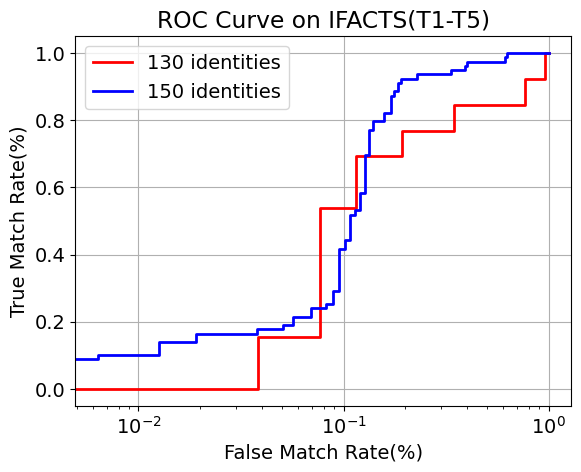

In [9]:
from sklearn.metrics import roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df1 = pd.read_csv("archive/train_chestXray14_test_IFACTS/trained_model_ROC_curve_IFACTS_small.csv")
df2 = pd.read_csv("archive/train_chestXray14_test_IFACTS/trained_model_ROC_curve_IFACTS_small_cropped.csv")
df3 = pd.read_csv("/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/CXR-Patient-ReID/PatientVerification/archive/ResNet50-100ID-T1-T5-130-ids/ResNet50-100ID-T1-T5-130-ids_labels_predictions.txt", delimiter="\t")
df4 = pd.read_csv("/home/sonymd/Desktop/IFACTS/IFACTS-SPG-Radiography/CXR-Patient-ReID/PatientVerification/archive/ResNet50-100ID-T1-T5-150-ids/ResNet50-100ID-T1-T5-150-ids_labels_predictions.txt", delimiter="\t")

fprs1, tprs1, thresholds1 = roc_curve(df1["label"], df1["score"], pos_label=1)
fprs2, tprs2, thresholds2 = roc_curve(df2["label"], df2["score"], pos_label=1)
fprs3, tprs3, thresholds3 = roc_curve(df3["Label"], df3["Prediction"], pos_label=1)
fprs4, tprs4, thresholds4 = roc_curve(df4["Label"], df4["Prediction"], pos_label=1)

plt.rcParams["font.size"]=14
plt.rcParams["lines.linewidth"]=2
fig = plt.Figure(figsize=(20,12), dpi=300)
# plt.semilogx(fprs1*100, tprs1*100, color="r", label="Before Cropping (100 identities)")
# plt.semilogx(fprs2*100, tprs2*100, color="g", label="After Cropping (100 identities)")
plt.semilogx(fprs3, tprs3, color="r", label="130 identities")
plt.semilogx(fprs4, tprs4, color="b", label="150 identities")
plt.title("ROC Curve on IFACTS(T1-T5)")
plt.xlabel("False Match Rate(%)")
plt.ylabel("True Match Rate(%)")
plt.legend()
plt.grid()
plt.savefig("archive/comparison/ROC-semilog.png", dpi=300)
plt.show()
plt.close()


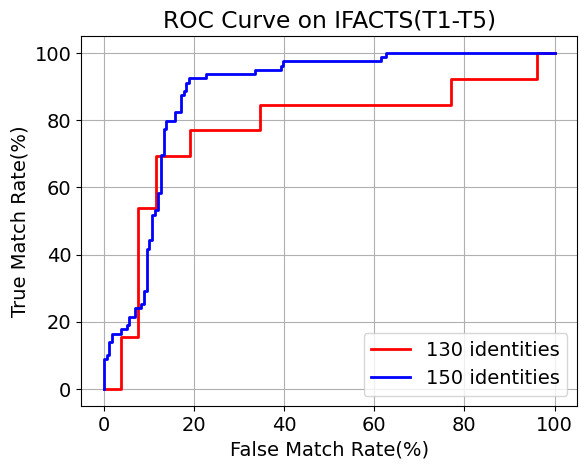

In [11]:
fig = plt.Figure(figsize=(20,12), dpi=300)
plt.plot(fprs3*100, tprs3*100, color="r", label="130 identities")
plt.plot(fprs4*100, tprs4*100, color="b", label="150 identities")
plt.title("ROC Curve on IFACTS(T1-T5)")
plt.xlabel("False Match Rate(%)")
plt.ylabel("True Match Rate(%)")
plt.legend(); plt.grid()
plt.savefig("archive/comparison/ROC-regular.png", dpi=300)
plt.show();plt.close()

In [ ]:
df

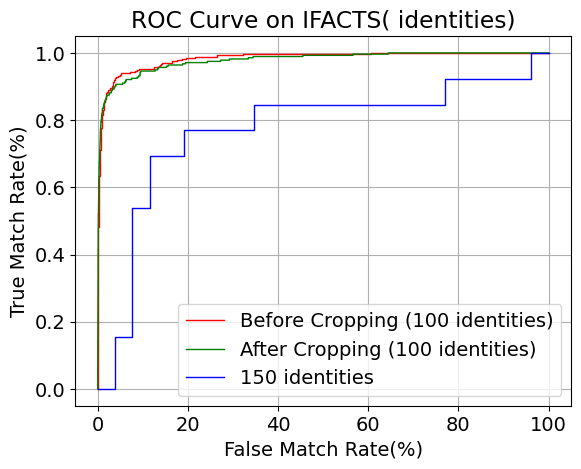

In [10]:




plt.rcParams["font.size"]=14
plt.Figure(figsize=(10,6), dpi=300)
plt.plot(fprs1*100, tprs1, linewidth=1, color="r", label="Before Cropping (100 identities)")
plt.plot(fprs2*100, tprs2, linewidth=1, color="g", label="After Cropping (100 identities)")
plt.plot(fprs3*100, tprs3, linewidth=1, color="b", label="150 identities")
plt.title("ROC Curve on IFACTS( identities)")
plt.xlabel("False Match Rate(%)")
plt.ylabel("True Match Rate(%)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
out = (df3["Prediction"] - df3["Prediction"].min())/(df3["Prediction"].max() - df3["Prediction"].min())

In [ ]:
# Calculating TMR at 1% FMR
TDR2 = np.interp(0.01, fprs2, tprs2)
print("True Detection Rate:", TDR2)

# Calculating TMR at 1% FMR
TDR1 = np.interp(0.01, fprs1, tprs1)
print("True Detection Rate:", TDR1)


# Calculating TMR at 1% FMR
TDR1 = np.interp(0.01, fprs3, tprs3)
print("True Detection Rate:", TDR1)

# ROC Comparison Between Models with and Without Bounding Box

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
df_reg = pd.read_csv("archive/ResNet50-100ID-T1-T5-150-ids-no-bounding-box/ResNet50-100ID-T1-T5-150-ids-no-bounding-box_ROC_metrics.txt", delimiter="\t")
df_box = pd.read_csv("archive/ResNet50-100ID-T1-T5-150-ids-with-bounding-box/ResNet50-100ID-T1-T5-150-ids-with-bounding-box_ROC_metrics.txt", delimiter="\t")

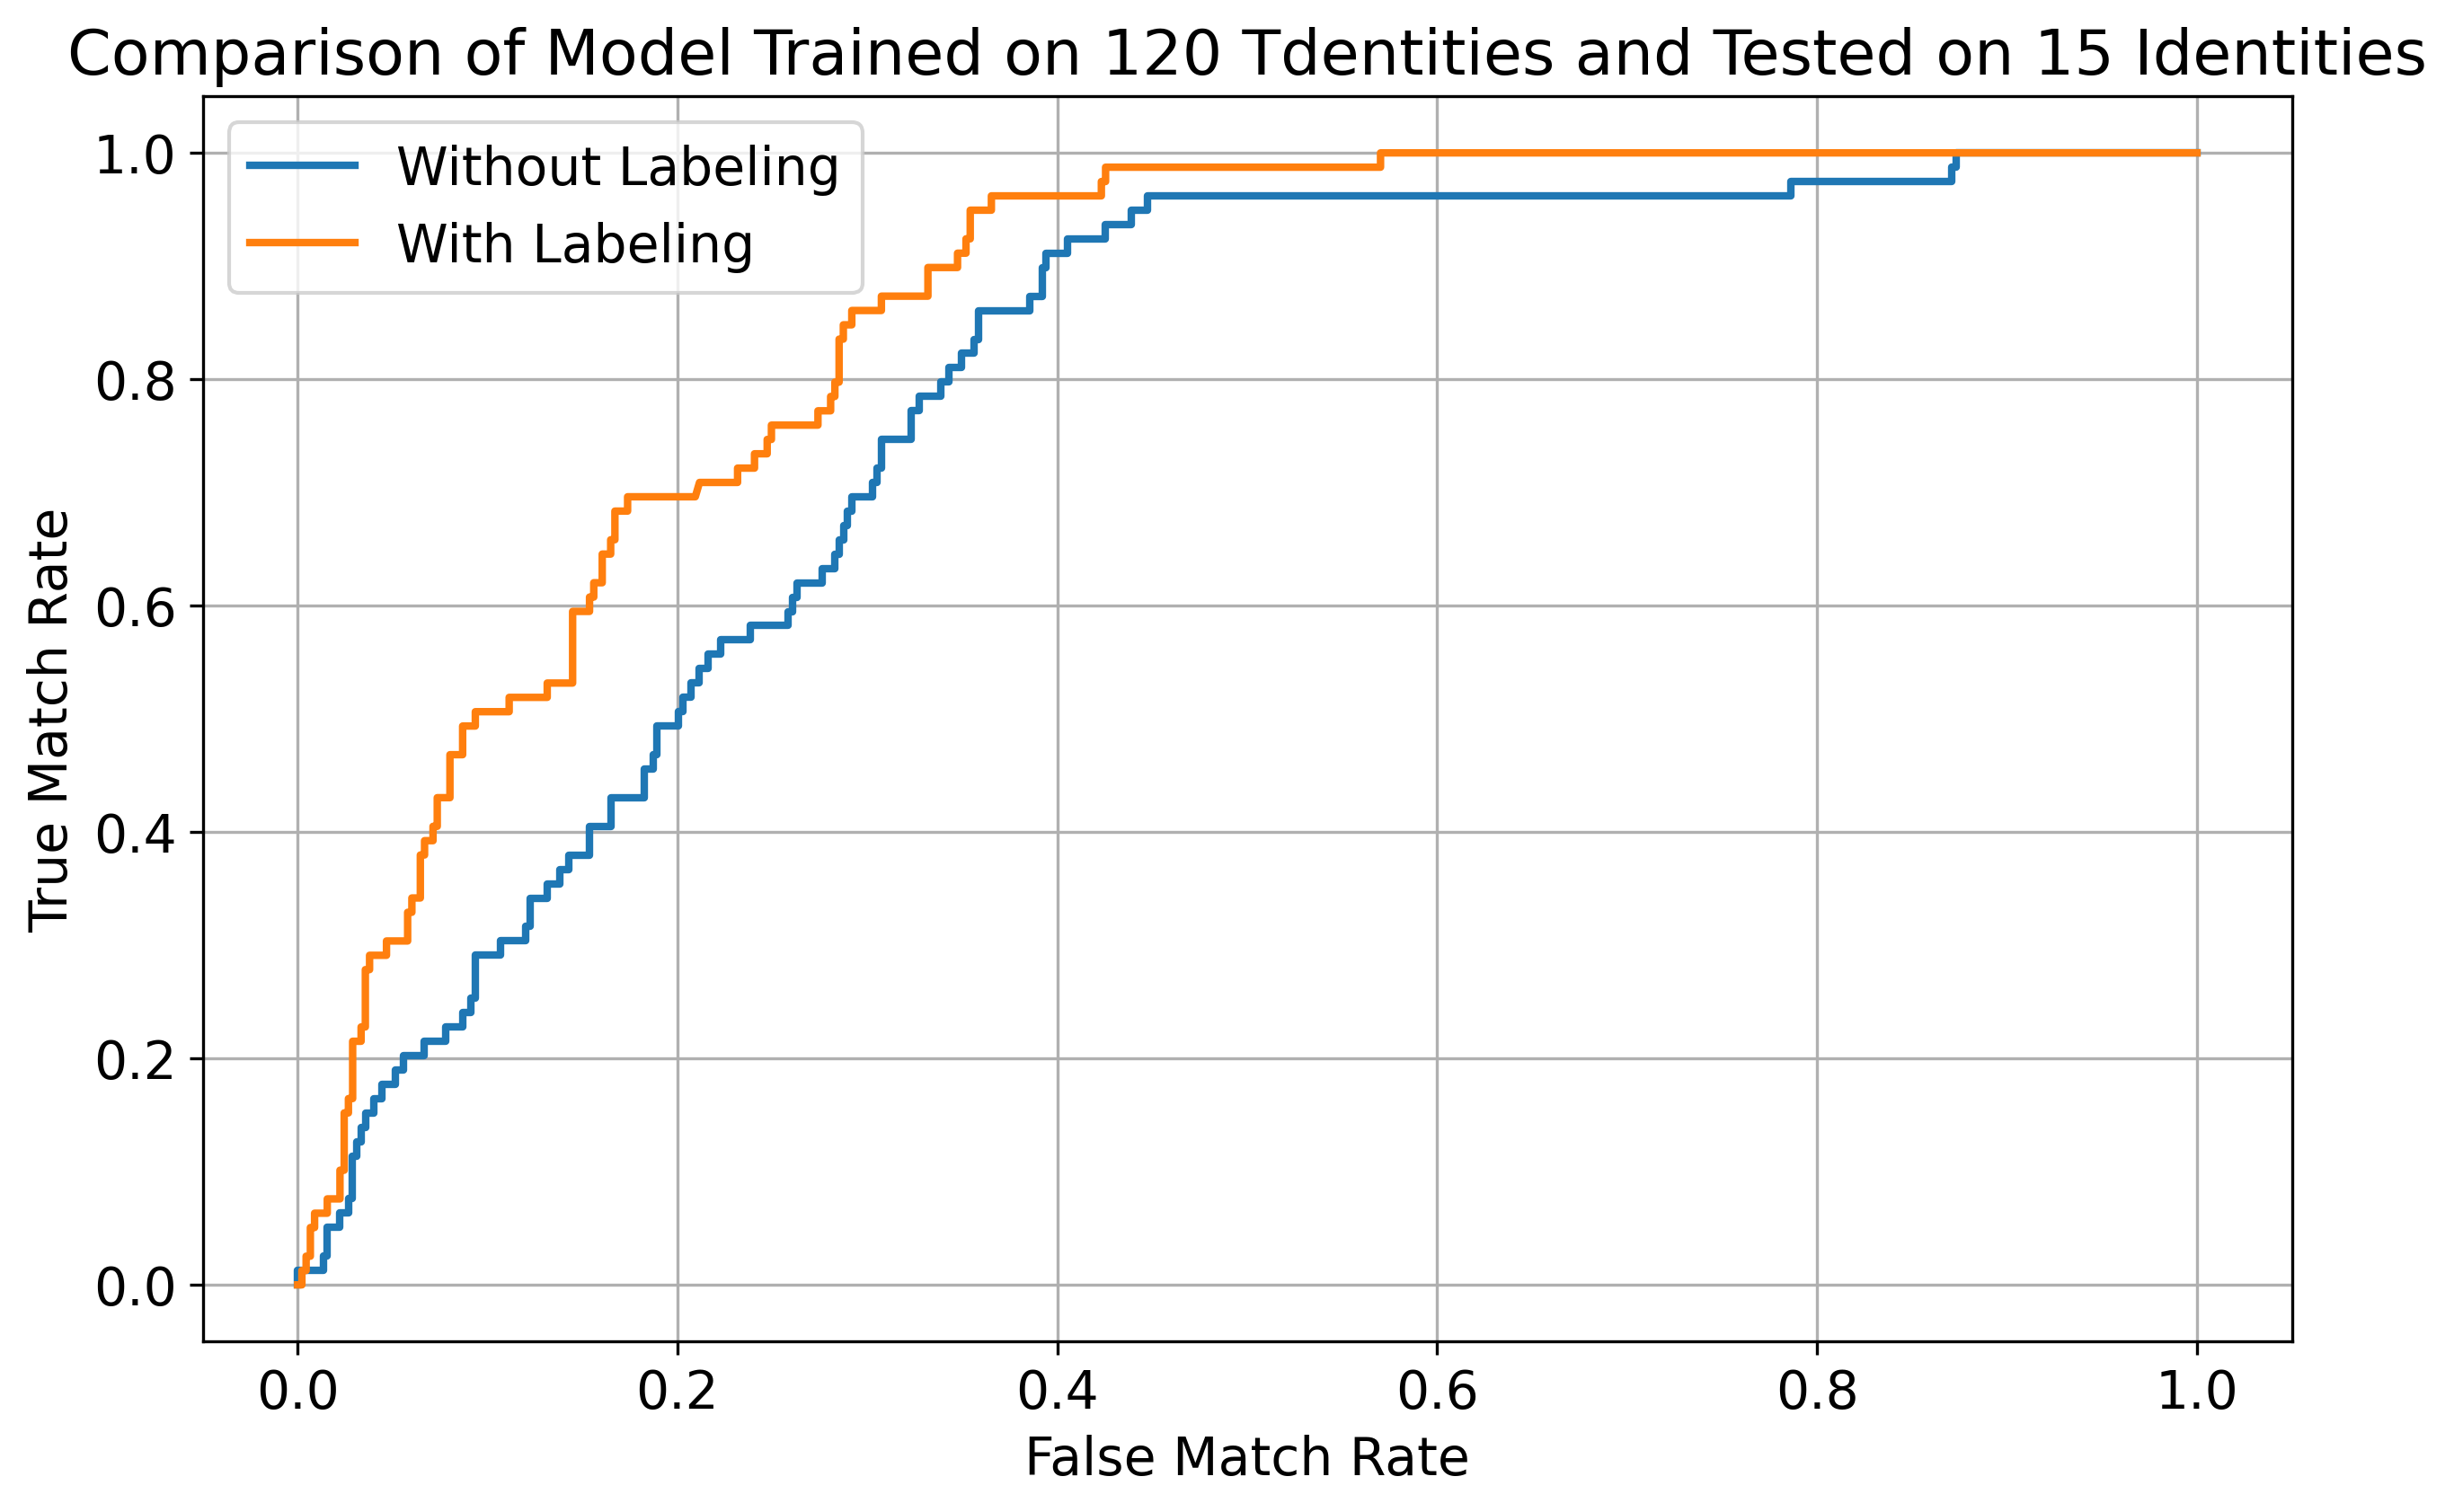

In [21]:
plt.figure(figsize=(10,6), dpi=300)


plt.rcParams["font.size"]=14
plt.rcParams["lines.linewidth"]=2
plt.plot(df_reg["FP_rate"], df_reg["TP_rate"], label="Without Labeling")
plt.plot(df_box["FP_rate"], df_box["TP_rate"], label="With Labeling")
plt.xlabel("False Match Rate"); plt.ylabel("True Match Rate"); plt.legend()
plt.grid(); plt.title("Comparison of Model Trained on 120 Tdentities and Tested on 15 Identities")
plt.savefig("archive/comparison/LabelingSignificance.png")

In [2]:
from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd
df3 = pd.read_csv("archive/ResNet50-100ID-T1-T5-150-ids-no-bounding-box/ResNet50-100ID-T1-T5-150-ids-no-bounding-box_labels_predictions.txt", delimiter="\t")
df4 = pd.read_csv("archive/ResNet50-100ID-T1-T5-150-ids-with-bounding-box/ResNet50-100ID-T1-T5-150-ids-with-bounding-box_labels_predictions.txt", delimiter="\t")
df5 = pd.read_csv("archive/ChestXray14Data-Small-Subset/ChestXray14Data-Small-Subset_labels_predictions.txt", delimiter="\t")

fprs3, tprs3, thresholds3 = roc_curve(df3["Label"], df3["Prediction"], pos_label=1)
fprs4, tprs4, thresholds4 = roc_curve(df4["Label"], df4["Prediction"], pos_label=1)
fprs5, tprs5, thresholds5 = roc_curve(df5["Label"], df5["Prediction"], pos_label=1)

# Calculating TMR at 1% FMR
TDR3 = np.interp(0.1, fprs3, tprs3)
print("True Detection Rate (No Labeling):", TDR3)

# Calculating TMR at 1% FMR
TDR4 = np.interp(0.1, fprs4, tprs4)
print("True Detection Rate (No Labeling):", TDR4)


# Calculating TMR at 1% FMR
TDR5 = np.interp(0.1, fprs5, tprs5)
print("True Detection Rate (No Labeling):", TDR5)

True Detection Rate (No Labeling): 0.2911392405063291
True Detection Rate (No Labeling): 0.5063291139240507
True Detection Rate (No Labeling): 0.25492212753452836


In [5]:
df_chestXray = pd.read_csv("archive/ChestXray14Data-Small-Subset/ChestXray14Data-Small-Subset_ROC_metrics.txt", delimiter='\t')
df_280 = pd.read_csv("archive/ResNet50-T1-T5-280-ids-with-bounding-box/ResNet50-T1-T5-280-ids-with-bounding-box_ROC_metrics.txt", delimiter='\t')

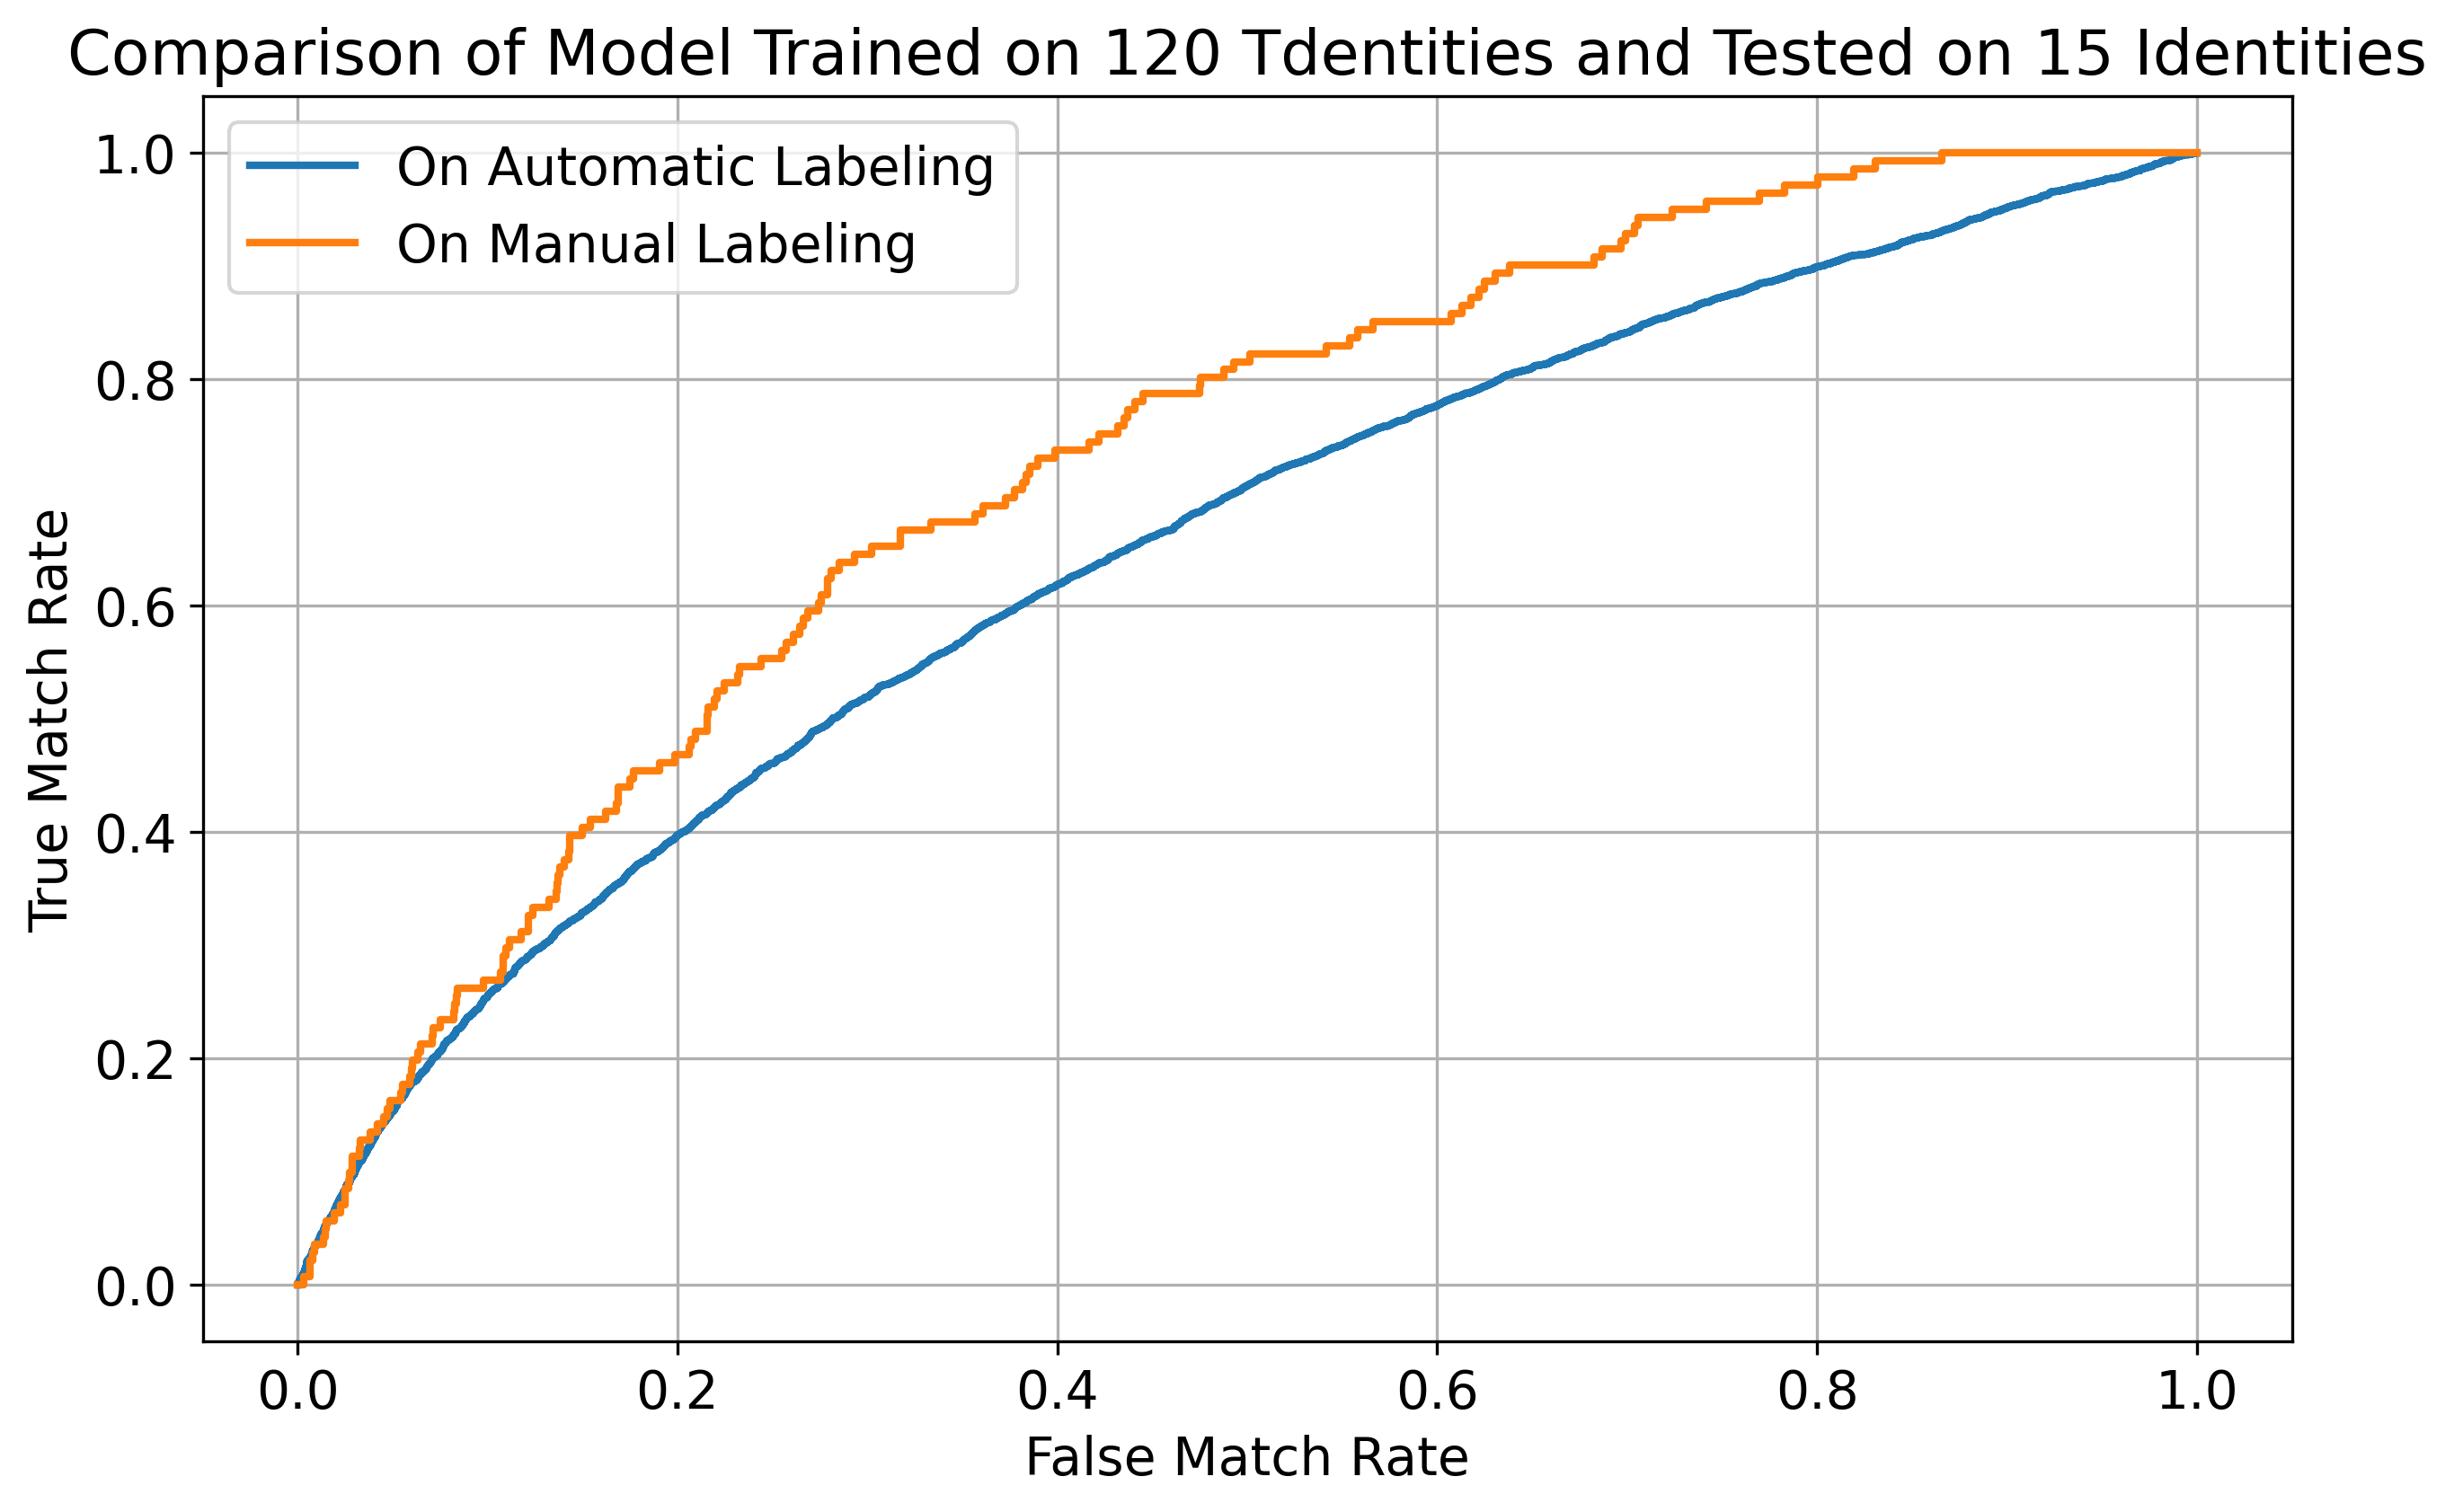

In [7]:
plt.figure(figsize=(10,6), dpi=300)


plt.rcParams["font.size"]=14
plt.rcParams["lines.linewidth"]=2
plt.plot(df_chestXray["FP_rate"], df_chestXray["TP_rate"], label="On Automatic Labeling")
plt.plot(df_280["FP_rate"], df_280["TP_rate"], label="On Manual Labeling")
plt.xlabel("False Match Rate"); plt.ylabel("True Match Rate"); plt.legend()
plt.grid(); plt.title("Comparison of Model Trained on 120 Tdentities and Tested on 15 Identities")
plt.savefig("archive/comparison/LabelingSignificance.png")